# Notebook — Blade Tip Timing (BTT) as a Non-Uniform Sampling Spectral Analysis Problem

## 1) Introduction

Blade Tip Timing (BTT) is a **non-contact measurement technique** used in turbomachinery to measure blade vibrations during engine testing.

A set of probes (optical, capacitive, etc.) is mounted on the casing at **fixed angular positions**. Each time a blade tip passes in front of a probe, the probe records a **Time of Arrival (ToA)**, denoted $t_{b,s}(n)$ for blade $b$, sensor $s$, and revolution $n$.

<img src="images/image3.png" style="display:block; margin: 0 auto; width:300px;">

To relate timing measurements to blade motion, we compare the measured ToA to a **predicted non-vibrating ToA**. This requires a fixed angular reference on the rotor, provided by the **OPR (Once-Per-Revolution)** sensor, which delivers one timestamp per revolution $t_{\mathrm{OPR}}(n)$. From two successive OPR timestamps, the rotation frequency during revolution $n$ is estimated as:

$$
F_r(n) = \frac{1}{t_{\mathrm{OPR}}(n+1) - t_{\mathrm{OPR}}(n)},
\qquad
\Omega_n = 2\pi F_r(n).
$$

Using this estimated speed, the expected (non-vibrating) ToA at sensor angle $\theta_s$ is obtained from the blade phase $\varphi_b$ at the OPR reference:

$$
\widehat{t}_{b,s}(n)=
\begin{cases}
t_{\mathrm{OPR}}(n) + \dfrac{\theta_s-\varphi_b}{\Omega_n}, & \theta_s \ge \varphi_b,\\[6pt]
t_{\mathrm{OPR}}(n) + \dfrac{\theta_s-\varphi_b+2\pi}{\Omega_n}, & \theta_s < \varphi_b.
\end{cases}
$$

The **Tip Timing signal** is then defined as the deviation between the measured and nominal passage times, converted into a blade-tip displacement:

$$
\widehat{x}_{b,s}(n) = 2\pi R\,F_r(n)\,\big(t_{b,s}(n) - \widehat{t}_{b,s}(n)\big),
$$

where $R$ is the blade tip radius.

From a signal-processing point of view, these ToA measurements are **event-driven**: samples exist only at blade passages. This naturally leads to **non-uniform sampling in time**, and the data are typically **strongly under-sampled** with respect to the vibration frequencies of interest.


## 2) Warm Up Exercice

Now that the Tip-Timing principle and the main equations are established, we can turn this measurement setup into a signal-processing exercise.

The dataset provided here is a simulated tip-timing signal from a single blade, observed by multiple sensors.

In this first step, we load the simulated Tip-Timing dataset from signal.csv and visualize the blade-tip deflection as a function of time.

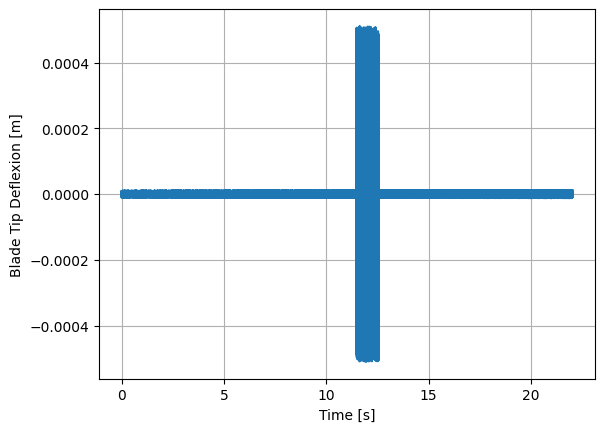

In [2]:
## This section Load and plot the Blade signal 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("signal.csv")

# Create explicit variables
Temps = df["Temps"].to_numpy().ravel()
Deflexion = df["Deplacement"].to_numpy().ravel()

plt.figure()
plt.plot(Temps, Deflexion)
plt.xlabel("Time [s]")
plt.ylabel("Blade Tip Deflexion [m]")
plt.grid(True)
plt.show()


#### Task 1 — Estimate the number of probes 
Determine how many probes  $N_c$ are installed around the casing.

In [3]:

# Use the time gaps:  Δt[k] = t[k+1] - t[k]
delta_t = np.diff(Temps)



#### Task 2 — Estimate the angular spacing between probes

Once $N_c$ is known, estimate the **angular separations** between consecutive probes:
$$
\Delta\theta_1,\ \Delta\theta_2,\ \dots,\ \Delta\theta_{N_c}.
$$




In [14]:

# After finding the Nc , Now you can estimate the angular separations between consecutive sensors 
Nc = # 
## ADD YOUR CODE HERE 
print("Angles spacements :  (deg) =", dtheta)

# For verification : Somme of angles differences should be 360 :) 



Angles spacements :  (deg) = [ 29.00009222  91.00051163 179.9997243   59.99967185]


## Signal Processing Exercise

#### Why a spectrogram is needed ? 



Many signals are **non-stationary**, meaning their frequency content changes over time. In that case, a **single spectrum** computed on the full record can hide short events or changes.

To track these variations, we use a Time-Frequency representation called , **spectrogram**: split the signal into short time windows, compute a spectrum (DFT) for each window, then stack the results to obtain a time–frequency map.

### Task 1 - Split the signal and compute the spectrogram using a simple DFT.



In [16]:
def DFTsimple(x, t, f, pow_=1):
    # x, t, f can be lists/arrays; we force 1D vectors
    x = np.asarray(x).ravel()
    t = np.asarray(t).ravel()
    f = np.asarray(f).ravel()

    # local time-steps (handles non-uniform sampling)
    dt  = np.diff(t)
    dts = 0.5 * (np.r_[dt, 0] + np.r_[0, dt])                  # symmetric dt

    # non-uniform DFT matrix
    W = np.exp(-2j*np.pi * f[:, None] * t[None, :])            # (Nf x N)

    return W @ (x * (dts**pow_))                               # (Nf,)





# Split the signal : 
Ndft = 256

# ADD your code here 





#Calculate DFT on each interval 
for ii in range(Nwin):

    # ADD your code here 
    XFT  = ### 
    
plt.figure()
plt.imshow(np.abs(XFT), origin="lower", aspect="auto")
plt.xlabel("Window index")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram (simple DFT, non-uniform t)")
plt.colorbar(label="|X(f)|")
plt.show()
plt.set_cmap("jet")








## Task 2 — Single-segment spectrum (DFT)

To reduce computation time, we now focus on **one short time interval** only.
The goal is to compute a spectrum on a **single window** located in a vibration region.

**Task:** Select one time segment (window) and plot its spectrum using a simple **DFT** (non-uniform time support).



In [3]:
# --- choose one window and plot its spectrum
win =   # window index

xw = X[:, win]          # displacement in that window
tw = T[:, win]          # time instants in that window

Xw = DFTsimple(xw, tw, Frequencies, 1)


# Plot here 



SyntaxError: invalid syntax (2352870499.py, line 2)

### Task 3 -  Single-segment spectrum with OMP
For the same time window, estimate its spectrum using OMP.
OMP is a greedy sparse-recovery algorithm that builds the solution iteratively by selecting, at each step, the frequency atom that best matches the current residual.

In [4]:

def OMPsimple(x, t, f, thr=1e-5):
    x = np.asarray(x).ravel().astype(float)
    t = np.asarray(t).ravel()
    f = np.asarray(f).ravel()
    A = np.exp(1j * 2*np.pi * t[:, None] * f[None, :])   # (N x Nf)
    r = x.copy()
    SS = []
    while np.vdot(r, r).real > thr:
        Z = np.abs(A.conj().T @ r)
        pos = int(np.argmax(Z))
        if pos in SS:
            break
        SS.append(pos)
        SS.sort()

        AS = A[:, SS]
        xS = np.linalg.pinv(AS) @ x
        r  = x - np.real(AS @ xS)
    Xomp = np.zeros(len(f), dtype=complex)
    Xomp[SS] = xS
    return Xomp, SS




# --- choose one window and plot its spectrum (OMP)
win = 




NameError: name 'X' is not defined